In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

print("Libraries loaded")

Libraries loaded


In [2]:
# Cell 2: Load Processed Data
X_train = pd.read_csv('../data/processed/X_train.csv', index_col=0)
y_train = pd.read_csv('../data/processed/y_train.csv', index_col=0).squeeze()
X_val = pd.read_csv('../data/processed/X_val.csv', index_col=0)
y_val = pd.read_csv('../data/processed/y_val.csv', index_col=0).squeeze()
X_test = pd.read_csv('../data/processed/X_test.csv', index_col=0)
y_test = pd.read_csv('../data/processed/y_test.csv', index_col=0).squeeze()

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (95530, 8), Val: (20471, 8), Test: (20471, 8)


In [3]:
# Cell 3: Train Random Forest
print("Training Random Forest...")

model = RandomForestRegressor()

model.fit(X_train, y_train)
print("Random Forest trained")

Training Random Forest...
Random Forest trained


In [4]:
# Cell 4: Make Predictions
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

print("Predictions made")

Predictions made


In [5]:
# Cell 5: Calculate Metrics
def calculate_metrics(y_true, y_pred, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{set_name} Set Metrics:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R²:   {r2:.4f}")
    
    return {'RMSE': rmse, 'MAE': mae, 'R²': r2}

train_metrics = calculate_metrics(y_train, y_train_pred, "Train")
val_metrics = calculate_metrics(y_val, y_val_pred, "Validation")
test_metrics = calculate_metrics(y_test, y_test_pred, "Test")


Train Set Metrics:
  RMSE: 150.7455
  MAE:  51.1468
  R²:   0.8532

Validation Set Metrics:
  RMSE: 152.8359
  MAE:  53.8887
  R²:   0.8080

Test Set Metrics:
  RMSE: 136.6113
  MAE:  46.2122
  R²:   0.8422


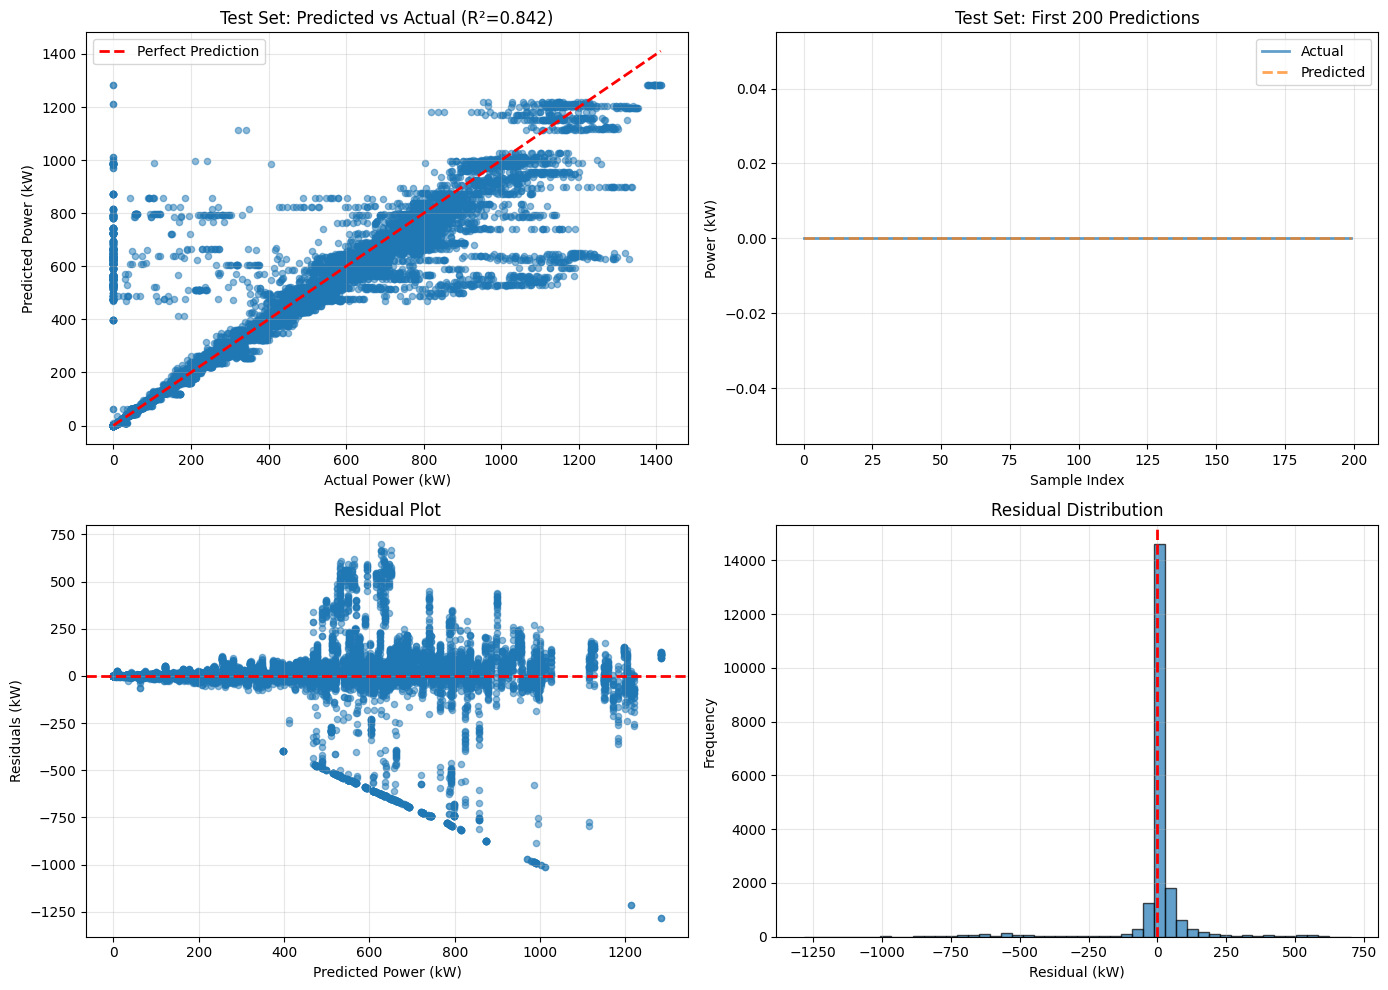

In [6]:
# Cell 7: Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Predicted vs Actual (Test Set)
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.5, s=20)
axes[0, 0].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Power (kW)')
axes[0, 0].set_ylabel('Predicted Power (kW)')
axes[0, 0].set_title(f'Test Set: Predicted vs Actual (R²={test_metrics["R²"]:.3f})')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Time Series Comparison (First 200 test samples)
axes[0, 1].plot(y_test.values[:200], label='Actual', 
                linewidth=2, alpha=0.7)
axes[0, 1].plot(y_test_pred[:200], label='Predicted', 
                linewidth=2, alpha=0.7, linestyle='--')
axes[0, 1].set_xlabel('Sample Index')
axes[0, 1].set_ylabel('Power (kW)')
axes[0, 1].set_title('Test Set: First 200 Predictions')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Residuals
residuals = y_test - y_test_pred
axes[1, 0].scatter(y_test_pred, residuals, alpha=0.5, s=20)
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Power (kW)')
axes[1, 0].set_ylabel('Residuals (kW)')
axes[1, 0].set_title('Residual Plot')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Residual Distribution
axes[1, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Residual (kW)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residual Distribution')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



MODEL COMPARISON
            Model  Test_RMSE  Test_MAE  Test_R²
Linear Regression 152.064091 83.554062 0.804540
    Random Forest 136.611297 46.212159 0.842247

R² Improvement: 4.7%


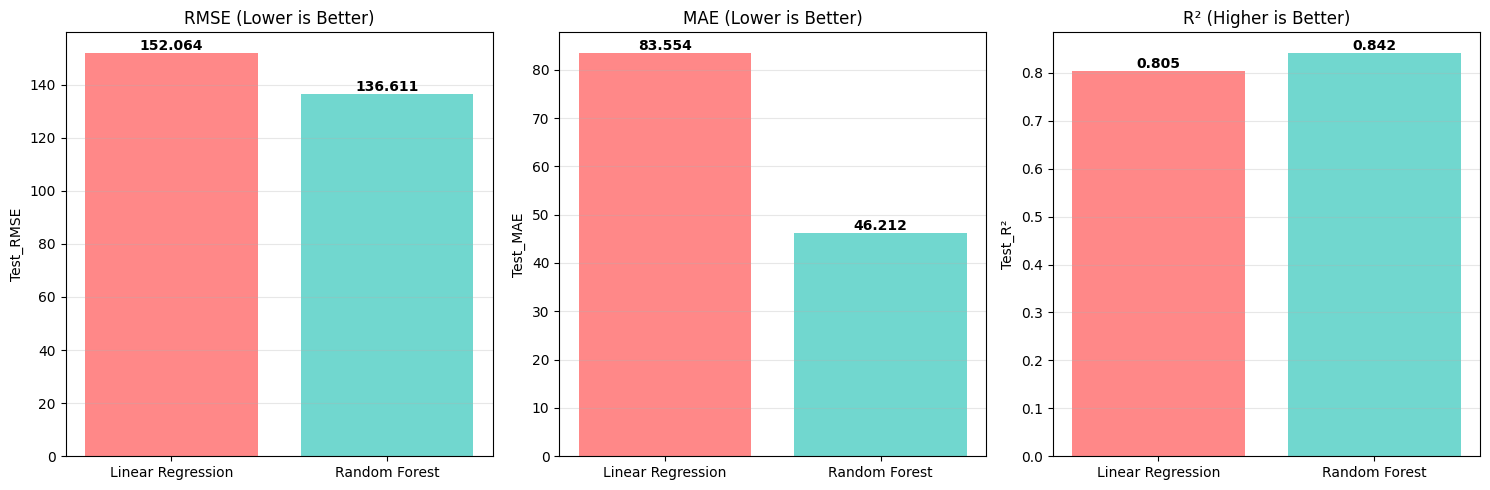

In [7]:
# Cell 8: Compare with Linear Regression
lr_metrics = pd.read_csv('../models/linear_regression_metrics.csv')

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'Test_RMSE': [lr_metrics['Test_RMSE'].values[0], test_metrics['RMSE']],
    'Test_MAE': [lr_metrics['Test_MAE'].values[0], test_metrics['MAE']],
    'Test_R²': [lr_metrics['Test_R²'].values[0], test_metrics['R²']]
})

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison.to_string(index=False))
print("="*60)

# Improvement calculation
r2_improvement = ((test_metrics['R²'] - lr_metrics['Test_R²'].values[0]) / 
                   lr_metrics['Test_R²'].values[0] * 100)
print(f"\nR² Improvement: {r2_improvement:.1f}%")
print("="*60)

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = ['Test_RMSE', 'Test_MAE', 'Test_R²']
titles = ['RMSE (Lower is Better)', 'MAE (Lower is Better)', 'R² (Higher is Better)']

for idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    axes[idx].bar(comparison['Model'], comparison[metric], 
                  color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
    axes[idx].set_ylabel(metric)
    axes[idx].set_title(title)
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, v in enumerate(comparison[metric]):
        axes[idx].text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
# Cell 10: Save Model and Metrics
joblib.dump(model, '../models/random_forest.pkl')
print("\n Model saved to ../models/random_forest.pkl")

# Save metrics
rf_metrics_df = pd.DataFrame({
    'Model': ['Random Forest'],
    'Train_RMSE': [train_metrics['RMSE']],
    'Train_MAE': [train_metrics['MAE']],
    'Train_R²': [train_metrics['R²']],
    'Val_RMSE': [val_metrics['RMSE']],
    'Val_MAE': [val_metrics['MAE']],
    'Val_R²': [val_metrics['R²']],
    'Test_RMSE': [test_metrics['RMSE']],
    'Test_MAE': [test_metrics['MAE']],
    'Test_R²': [test_metrics['R²']]
})

rf_metrics_df.to_csv('../models/random_forest_metrics.csv', index=False)
print("Metrics saved to ../models/random_forest_metrics.csv")


 Model saved to ../models/random_forest.pkl
Metrics saved to ../models/random_forest_metrics.csv


In [9]:
# Cell 11: Summary
print("RANDOM FOREST COMPLETE")
print(f"Test R²:   {test_metrics['R²']:.4f}")
print(f"Test RMSE: {test_metrics['RMSE']:.4f} kW")
print(f"Test MAE:  {test_metrics['MAE']:.4f} kW")

RANDOM FOREST COMPLETE
Test R²:   0.8422
Test RMSE: 136.6113 kW
Test MAE:  46.2122 kW
